In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import pathlib
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\gurup\OneDrive\Desktop\AI-Skin-Classifier\Data sets"   # update to match your actual path

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

data_dir = pathlib.Path(DATA_DIR)
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir() and not d.name.startswith('.')])
print("Classes found:", class_names)
assert len(class_names) == 6, f"Expected 6 class folders, found {len(class_names)}: {class_names}"

Classes found: ['acne', 'blackheads', 'clearskin', 'darkspots', 'pores', 'wrinkles']


In [2]:
full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, labels="inferred", label_mode="categorical",
    image_size=IMG_SIZE, batch_size=None, shuffle=True, seed=SEED,
)

total = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.70 * total)
val_size = int(0.15 * total)

train_ds = full_ds.take(train_size)
remaining = full_ds.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

import collections
counts = collections.Counter()
for _, label in full_ds:
    counts[class_names[int(tf.argmax(label).numpy())]] += 1

print(f"Total: {total} | train: {train_size} | val: {val_size} | test: {total-train_size-val_size}")
print("Per-class counts:", dict(counts))

total_n = sum(counts.values())
class_weight = {i: total_n / (len(class_names) * counts[name]) for i, name in enumerate(class_names)}
print("Class weights:", class_weight)


Found 11323 files belonging to 6 classes.
Total: 11323 | train: 7926 | val: 1698 | test: 1699
Per-class counts: {'acne': 2060, 'darkspots': 2126, 'pores': 1632, 'clearskin': 1553, 'wrinkles': 1982, 'blackheads': 1970}
Class weights: {0: 0.9161003236245955, 1: 0.9579526226734348, 2: 1.2151749302425414, 3: 0.8876607086861085, 4: 1.1563521241830066, 5: 0.9521527077026573}


In [3]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name="augmentation")

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def prep_train(x, y):
    return preprocess(data_augmentation(x)), y

def prep_eval(x, y):
    return preprocess(x), y

AUTOTUNE = tf.data.AUTOTUNE
train_ds_p = train_ds.batch(BATCH_SIZE).map(prep_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_p   = val_ds.batch(BATCH_SIZE).map(prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_p  = test_ds.batch(BATCH_SIZE).map(prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
print("Pipeline ready.")


Pipeline ready.


In [4]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=loss_fn, metrics=["accuracy"])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,427,846 (9.26 MB)

 Trainable params: 167,302 (653.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_mobilenetv2_model.keras", monitor="val_accuracy", save_best_only=True),
]

print("Phase 1: training the head, backbone frozen...")
history1 = model.fit(train_ds_p, validation_data=val_ds_p, epochs=15,
                      class_weight=class_weight, callbacks=callbacks)


Phase 1: training the head, backbone frozen...
Epoch 1/15


C:\Users\gurup\anaconda_projects\New folder\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


248/248 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.7499 - loss: 1.0501 - val_accuracy: 0.8669 - val_loss: 0.7539
Epoch 2/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.8322 - loss: 0.8324 - val_accuracy: 0.8740 - val_loss: 0.7373
Epoch 3/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 243s 971ms/step - accuracy: 0.8617 - loss: 0.7697 - val_accuracy: 0.9034 - val_loss: 0.6792
Epoch 4/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 237s 949ms/step - accuracy: 0.8799 - loss: 0.7298 - val_accuracy: 0.9105 - val_loss: 0.6648
Epoch 5/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.8866 - loss: 0.7115 - val_accuracy: 0.9011 - val_loss: 0.6771
Epoch 6/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 238s 953ms/step - accuracy: 0.8958 - loss: 0.6907 - val_accuracy: 0.9028 - val_loss: 0.6734
Epoch 7/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.8887 - loss: 0.6992 - val_accuracy: 0.8857 - val_loss: 0.6985
Epoch 8/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.8997 - loss: 0.6832 - val_accura

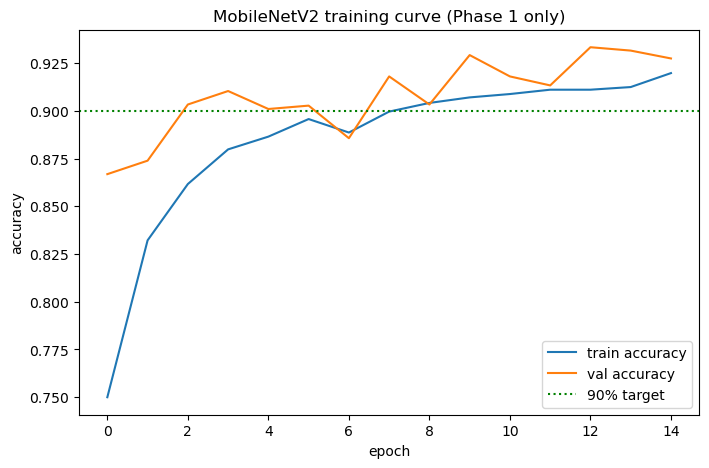

In [7]:
acc = history1.history["accuracy"]
val_acc = history1.history["val_accuracy"] 
plt.figure(figsize=(8,5))
plt.plot(acc, label="train accuracy") 
plt.plot(val_acc, label="val accuracy")
plt.axhline(y=0.90, color="green", linestyle=":", label="90% target") 
plt.xlabel("epoch"); plt.ylabel("accuracy");
plt.legend();
plt.title("MobileNetV2 training curve (Phase 1 only)")
plt.show()

In [8]:
def predict_with_tta(images, n_views=5):
    preds_sum = 0
    for _ in range(n_views):
        augmented = data_augmentation(images, training=True)
        augmented = preprocess(augmented)
        preds_sum += model.predict(augmented, verbose=0)
    return preds_sum / n_views

# Plain (no-TTA) evaluation for comparison
plain_loss, plain_acc = model.evaluate(test_ds_p)
print(f"Plain test accuracy (no TTA): {plain_acc*100:.2f}%")

# TTA evaluation
y_true, y_pred_tta = [], []
for x_batch, y_batch in test_ds.batch(BATCH_SIZE):
    probs = predict_with_tta(x_batch, n_views=5)
    y_true.extend(tf.argmax(y_batch, axis=1).numpy())
    y_pred_tta.extend(np.argmax(probs, axis=1))

from sklearn.metrics import accuracy_score
tta_acc = accuracy_score(y_true, y_pred_tta)
print(f"\n{'='*55}")
print(f"FINAL TEST ACCURACY (with TTA): {tta_acc*100:.2f}%")
print(f"{'='*55}")

if tta_acc >= 0.90:
    print("Target reached.")
else:
    gap = (0.90 - tta_acc) * 100
    print(f"{gap:.1f} points short. Check (in order of impact):")
    print("  1. More images per class -- the single biggest lever")
    print("  2. Confusion matrix below: which class is weakest? Recheck those photos by eye")
    print("  3. Cross-source giveaways: is the model learning photo style, not skin condition?")
    print("  4. Try merging visually-overlapping classes (redness/acne often blur together)")


54/54 ━━━━━━━━━━━━━━━━━━━━ 54s 706ms/step - accuracy: 0.9305 - loss: 0.6245
Plain test accuracy (no TTA): 93.05%

FINAL TEST ACCURACY (with TTA): 95.82%
Target reached.


In [9]:
model.save("skin_condition_mobilenetv2.keras")
print("Saved to skin_condition_mobilenetv2.keras")

def predict_single_image(img_path, use_tta=True, n_views=5):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)

    if use_tta:
        probs = predict_with_tta(arr, n_views=n_views)[0]
    else:
        probs = model.predict(preprocess(arr), verbose=0)[0]

    ranked = sorted(zip(class_names, probs), key=lambda x: x[1], reverse=True)
    return ranked


result = predict_single_image(r"C:\Users\gurup\OneDrive\Desktop\AI-Skin-Classifier\Data sets\clearskin\000001.jpg")
for label, prob in result:
    print(f"{label}: {prob*100:.1f}%")


Saved to skin_condition_mobilenetv2.keras
clearskin: 84.7%
darkspots: 4.5%
blackheads: 3.7%
wrinkles: 2.7%
acne: 2.2%
pores: 2.2%
